# Analysis of the grades

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Grade categories
categories = ["Good", "Almost", "Wrong"]

# First and second grades
grades_first = [
    "Good", "Wrong", "Almost", "Good",
    "Good", "Good", "Almost", "Almost",
    "Almost", "Good", "Wrong", "Almost",
    "Good", "Good", "Good", "Good"
]

grades_second = [
    "Good", "Good", "Good", "Almost",
    "Almost", "Almost", "Almost", "Good",
    "Almost", "Almost", "Almost", "Wrong",
    "Good", "Good", "Almost", "Good"
]


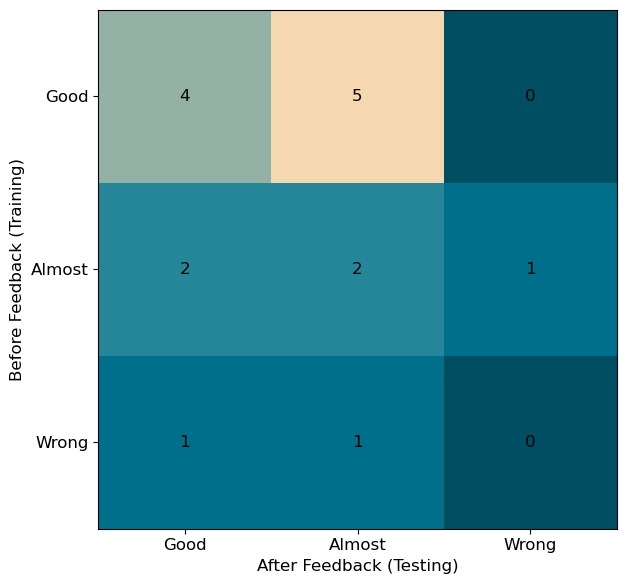

In [27]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
from matplotlib.colors import LinearSegmentedColormap

def invert(colors):
    return [colors[i] for i in reversed(range(len(colors)))]

custom_colors = ["#f5d7b0","#7ba8a3", "#3e909d", "#007896", "#004e61"]
custom_colors = invert(custom_colors)
cmap = LinearSegmentedColormap.from_list("custom_map", custom_colors)

conf_matrix = np.zeros((len(categories), len(categories)), dtype=int)
cat_to_idx = {c: i for i, c in enumerate(categories)}
for g1, g2 in zip(grades_first, grades_second):
    conf_matrix[cat_to_idx[g1], cat_to_idx[g2]] += 1

# Plot heatmap with matplotlib only (default colormap)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf_matrix, cmap=cmap)

# Ticks and labels
ax.set_xticks(range(len(categories)))
ax.set_yticks(range(len(categories)))
ax.set_xticklabels(categories)
ax.set_yticklabels(categories)

# Correct axis orientation labels
ax.set_xlabel("After Feedback (Testing)")
ax.set_ylabel("Before Feedback (Training)")
#ax.set_title("Transition of Grades (First → Second Experiment)")

# Cell annotations
for (i, j), val in np.ndenumerate(conf_matrix):
    ax.text(j, i, str(val), ha="center", va="center")

plt.tight_layout()
plt.show()